# Exploratory Data Analysis (EDA)

## Ontario Electricity Peak-Risk Forecasting

This notebook performs exploratory data analysis on the final regional analytical datasets produced by the data preparation pipeline.

The EDA focuses on understanding the temporal behaviour of hourly electricity demand and its relationship with the selected weather and calendar variables.

The analysis is designed to support subsequent forecasting and peak-risk modeling while remaining separate from predictive feature engineering and model training.

### Study Regions

- **Downtown:** M5S + M5R + M6G
- **Airport-West:** L4T + M9W + M9R

### EDA Objectives

The analysis will examine:

1. Dataset structure and analytical readiness.
2. Electricity-demand distributions and potential anomalies.
3. Long-term demand behaviour.
4. Hourly, daily, weekly, monthly, and seasonal patterns.
5. Temperature and humidity relationships with electricity demand.
6. Calendar effects such as weekends, workdays, and public holidays.
7. Autocorrelation and temporal dependence relevant to time-series forecasting.
8. High-demand behaviour relevant to subsequent peak-risk modeling.

No predictive models are trained in this notebook.

In [ ]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# Project paths

DATA_PATH = Path("../data/processed")

DOWNTOWN_FILE = DATA_PATH / "master_hourly_downtown.csv"
AIRPORT_WEST_FILE = DATA_PATH / "master_hourly_airport_west.csv"

## 1. Data Loading

The EDA uses only the validated regional analytical datasets generated by the data preparation pipeline.

Raw, intermediate, consumption, weather, and calendar source files are not reprocessed in this notebook.

In [5]:
# Load final analytical datasets

downtown = pd.read_csv(
    DOWNTOWN_FILE,
    parse_dates=["TIMESTAMP", "date"]
)

airport_west = pd.read_csv(
    AIRPORT_WEST_FILE,
    parse_dates=["TIMESTAMP", "date"]
)

print("Downtown shape:", downtown.shape)
print("Airport-West shape:", airport_west.shape)

Downtown shape: (43824, 16)
Airport-West shape: (43824, 16)


## 2. Initial Analytical Validation

A minimal validation is performed after loading the exported datasets to confirm that the expected analytical structure has been preserved.

This validation does not repeat the data-cleaning process.

In [6]:
# Minimal post-load validation

eda_initial_validation = []

datasets = {
    "DOWNTOWN": downtown,
    "AIRPORT_WEST": airport_west
}

for region, df in datasets.items():

    eda_initial_validation.append({
        "Region": region,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Unique_Timestamps": df["TIMESTAMP"].nunique(),
        "Duplicate_Timestamps": int(
            df["TIMESTAMP"].duplicated().sum()
        ),
        "Missing_Consumption": int(
            df["TOTAL_CONSUMPTION"].isna().sum()
        ),
        "Start": df["TIMESTAMP"].min(),
        "End": df["TIMESTAMP"].max()
    })

eda_initial_validation = pd.DataFrame(
    eda_initial_validation
)

eda_initial_validation

,Region,Rows,Columns,Unique_Timestamps,Duplicate_Timestamps,Missing_Consumption,Start,End
0,DOWNTOWN,43824,16,43824,0,0,2021-01-01,2025-12-31 23:00:00
1,AIRPORT_WEST,43824,16,43824,0,0,2021-01-01,2025-12-31 23:00:00


## 3. Electricity Demand Overview

This section examines the distribution and magnitude of hourly electricity demand in each study region.

The objective is to establish the basic statistical characteristics of the forecasting target before investigating temporal patterns, weather relationships, and high-demand behaviour.

Peak-risk thresholds are not defined at this stage because they must subsequently be estimated using training data only.

In [7]:
# Descriptive statistics for hourly electricity demand

demand_summary = []

for region, df in datasets.items():

    demand = df["TOTAL_CONSUMPTION"]

    demand_summary.append({
        "Region": region,
        "Count": demand.count(),
        "Mean": demand.mean(),
        "Median": demand.median(),
        "Std": demand.std(),
        "Min": demand.min(),
        "Q25": demand.quantile(0.25),
        "Q75": demand.quantile(0.75),
        "Max": demand.max(),
        "Skewness": demand.skew()
    })

demand_summary = pd.DataFrame(demand_summary)

demand_summary.round(2)

,Region,Count,Mean,Median,Std,Min,Q25,Q75,Max,Skewness
0,DOWNTOWN,43824,23258.9,22788.35,6114.39,10789.0,19001.88,27165.28,51768.3,0.45
1,AIRPORT_WEST,43824,29497.4,28529.10,9161.76,12917.0,22885.10,34314.30,76765.6,1.07


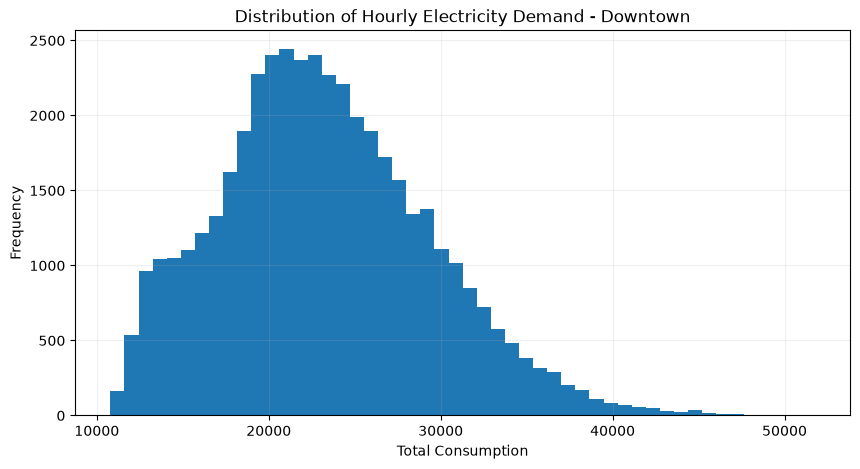

In [8]:
# Downtown hourly demand distribution

plt.figure(figsize=(10, 5))

plt.hist(
    downtown["TOTAL_CONSUMPTION"],
    bins=50
)

plt.title("Distribution of Hourly Electricity Demand - Downtown")
plt.xlabel("Total Consumption")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)

plt.show()

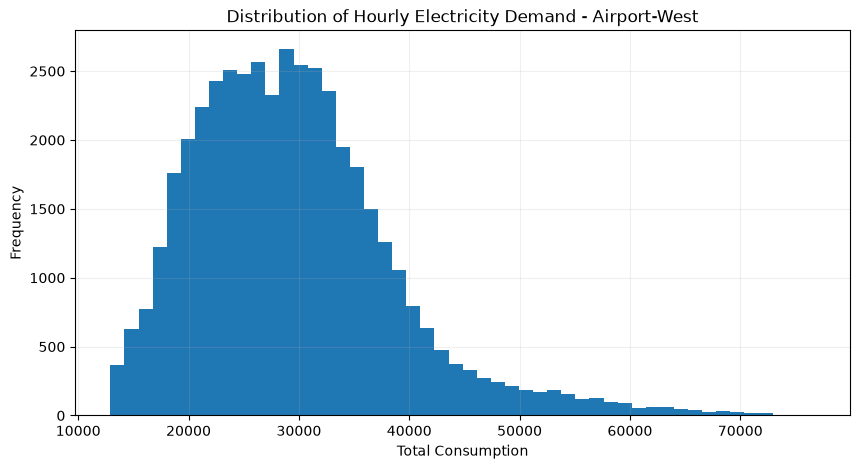

In [9]:
# Airport-West hourly demand distribution

plt.figure(figsize=(10, 5))

plt.hist(
    airport_west["TOTAL_CONSUMPTION"],
    bins=50
)

plt.title("Distribution of Hourly Electricity Demand - Airport-West")
plt.xlabel("Total Consumption")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)

plt.show()

### Demand Distribution Summary

Both regions exhibit positively skewed hourly electricity-demand distributions, although the magnitude and degree of asymmetry differ.

Downtown shows a moderately right-skewed distribution (skewness = 0.45), with mean hourly consumption of approximately 23,259 and relatively concentrated demand around its central range.

Airport-West exhibits higher average demand (approximately 29,497), greater variability, and stronger positive skewness (1.07). Its distribution contains a more pronounced upper tail, indicating more frequent or more extreme high-demand observations relative to its typical demand level.

High-demand observations are not treated as outliers at this stage. Because extreme electricity-demand conditions are directly relevant to the project's peak-risk objective, their temporal and operational characteristics must be investigated before considering any anomaly treatment.

## 4. Temporal Demand Behaviour

Electricity demand is inherently time-dependent. This section examines how regional demand changes over time and whether recurring temporal structures are present.

The analysis begins at a monthly aggregation level to identify long-term trends and broad seasonal behaviour before examining weekly and hourly demand patterns.

In [10]:
# Calculate monthly average electricity demand

monthly_demand = {}

for region, df in datasets.items():

    monthly = (
        df.set_index("TIMESTAMP")["TOTAL_CONSUMPTION"]
        .resample("MS")
        .mean()
        .reset_index()
    )

    monthly_demand[region] = monthly

    print(
        region,
        "| Months:", len(monthly),
        "| Start:", monthly["TIMESTAMP"].min(),
        "| End:", monthly["TIMESTAMP"].max()
    )

DOWNTOWN | Months: 60 | Start: 2021-01-01 00:00:00 | End: 2025-12-01 00:00:00
AIRPORT_WEST | Months: 60 | Start: 2021-01-01 00:00:00 | End: 2025-12-01 00:00:00


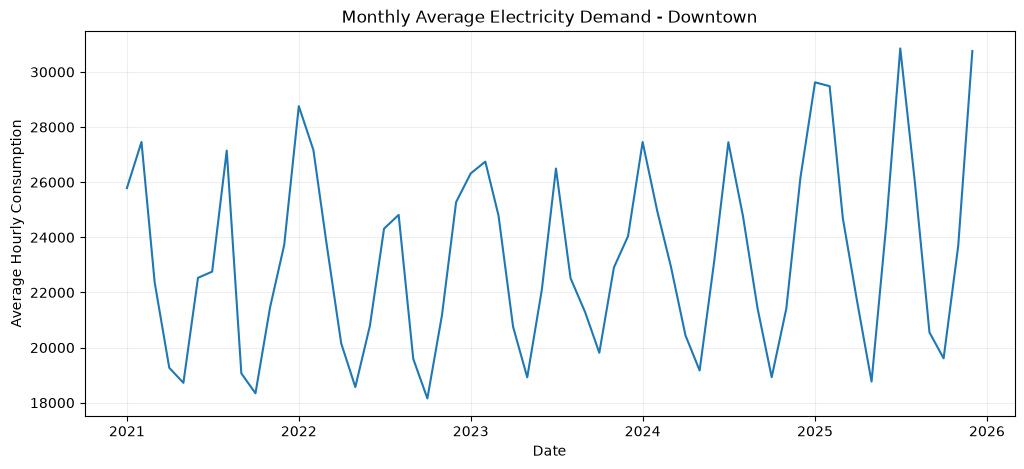

In [11]:
# Monthly average demand - Downtown

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["DOWNTOWN"]["TIMESTAMP"],
    monthly_demand["DOWNTOWN"]["TOTAL_CONSUMPTION"]
)

plt.title("Monthly Average Electricity Demand - Downtown")
plt.xlabel("Date")
plt.ylabel("Average Hourly Consumption")
plt.grid(alpha=0.2)

plt.show()

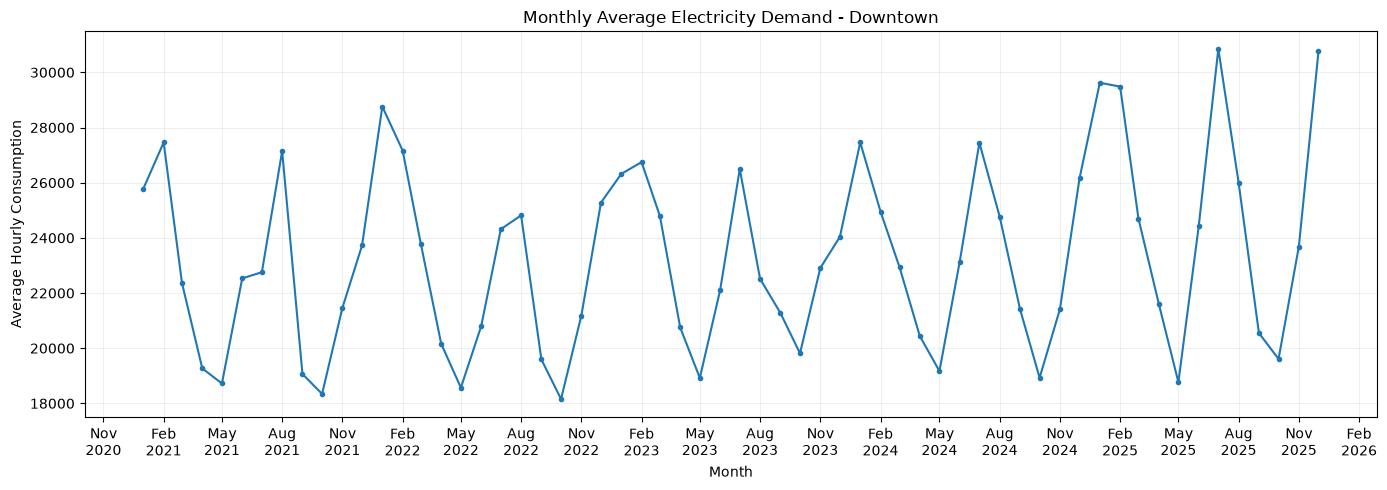

In [15]:
# Monthly average demand - Downtown

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_demand["DOWNTOWN"]["TIMESTAMP"],
    monthly_demand["DOWNTOWN"]["TOTAL_CONSUMPTION"],
    marker="o",
    markersize=3
)

ax.set_title("Monthly Average Electricity Demand - Downtown")
ax.set_xlabel("Month")
ax.set_ylabel("Average Hourly Consumption")

# Show one label every three months
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

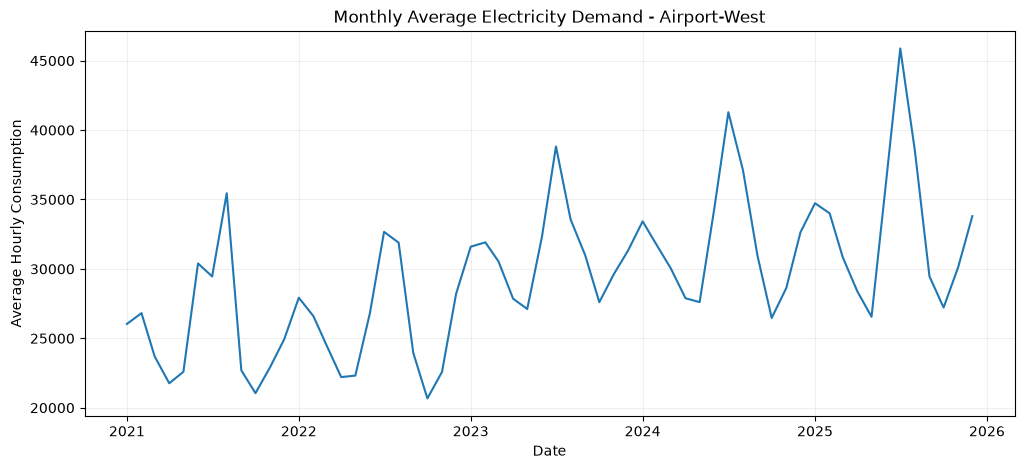

In [16]:
# Monthly average demand - Airport-West

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["AIRPORT_WEST"]["TIMESTAMP"],
    monthly_demand["AIRPORT_WEST"]["TOTAL_CONSUMPTION"]
)

plt.title("Monthly Average Electricity Demand - Airport-West")
plt.xlabel("Date")
plt.ylabel("Average Hourly Consumption")
plt.grid(alpha=0.2)

plt.show()

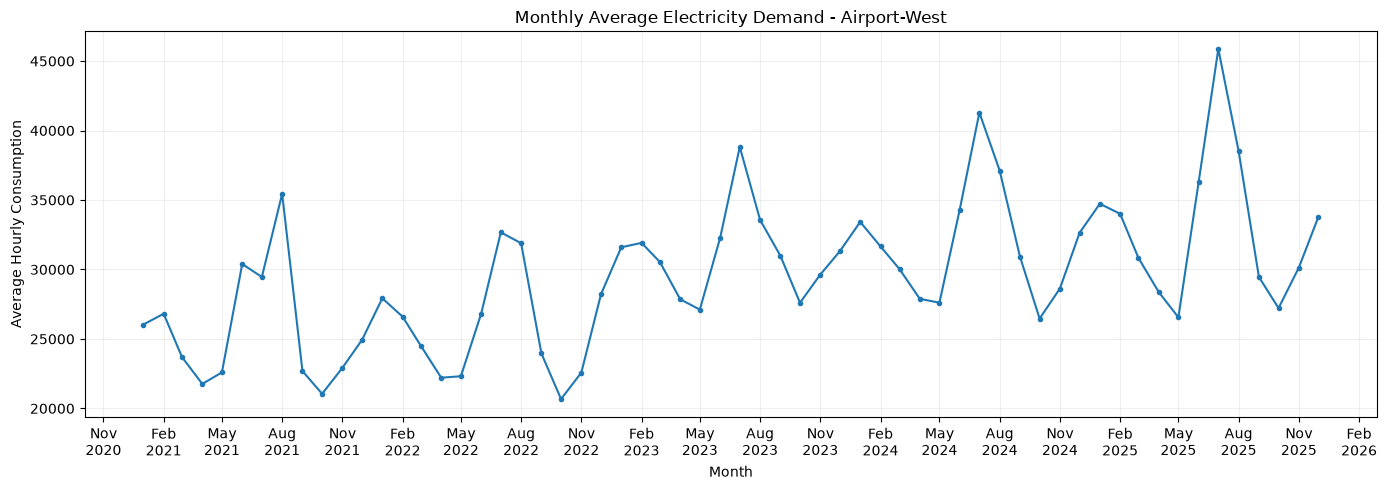

In [17]:
# Monthly average demand - Airport-West

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_demand["AIRPORT_WEST"]["TIMESTAMP"],
    monthly_demand["AIRPORT_WEST"]["TOTAL_CONSUMPTION"],
    marker="o",
    markersize=3
)

ax.set_title("Monthly Average Electricity Demand - Airport-West")
ax.set_xlabel("Month")
ax.set_ylabel("Average Hourly Consumption")

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [18]:
# Average demand by calendar month across all years

monthly_pattern = []

for region, df in datasets.items():

    pattern = (
        df.groupby("month")["TOTAL_CONSUMPTION"]
        .agg(["mean", "std"])
        .reset_index()
    )

    pattern["Region"] = region

    monthly_pattern.append(pattern)

monthly_pattern = pd.concat(
    monthly_pattern,
    ignore_index=True
)

monthly_pattern.round(2)

,month,mean,std,Region
0,1,27588.86,5105.93,DOWNTOWN
1,2,27146.60,4737.22,DOWNTOWN
2,3,23710.64,4339.41,DOWNTOWN
3,4,20446.14,3878.00,DOWNTOWN
4,5,18830.30,4244.37,DOWNTOWN
5,6,22596.88,6794.84,DOWNTOWN
6,7,26373.68,7193.85,DOWNTOWN
7,8,25049.43,6894.11,DOWNTOWN
8,9,20382.62,5347.37,DOWNTOWN
9,10,18969.95,4035.24,DOWNTOWN


### Monthly Demand Pattern Summary

Both regions exhibit clear recurring annual demand patterns, with higher electricity consumption during winter and summer and lower demand during the spring and fall transition periods.

Downtown shows a relatively consistent dual-season pattern. Average demand is highest in January and February, rises again during July and August, and reaches its lowest levels around May and October.

Airport-West exhibits a stronger summer-demand pattern. July has the highest average monthly demand and substantially greater variability than most other months. The chronological series also suggests that summer demand levels have increased across the study period.

These findings provide evidence of annual seasonality but do not establish stationarity or causality. The apparent long-term changes, particularly in Airport-West, require further temporal analysis before defining the SARIMAX specification.

In [19]:
# Average electricity demand by day of week

weekday_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_pattern = []

for region, df in datasets.items():

    pattern = (
        df.groupby("weekday")["TOTAL_CONSUMPTION"]
        .agg(["mean", "std"])
        .reset_index()
    )

    pattern["weekday_name"] = pattern["weekday"].map(
        dict(enumerate(weekday_names))
    )

    pattern["Region"] = region

    weekday_pattern.append(pattern)

weekday_pattern = pd.concat(
    weekday_pattern,
    ignore_index=True
)

weekday_pattern[
    ["Region", "weekday", "weekday_name", "mean", "std"]
].round(2)

,Region,weekday,weekday_name,mean,std
0,DOWNTOWN,0,Monday,23448.80,6293.93
1,DOWNTOWN,1,Tuesday,23378.54,6279.90
2,DOWNTOWN,2,Wednesday,23301.07,6174.51
3,DOWNTOWN,3,Thursday,23011.72,5870.04
4,DOWNTOWN,4,Friday,22953.44,5738.66
5,DOWNTOWN,5,Saturday,23144.45,5991.23
6,DOWNTOWN,6,Sunday,23573.35,6398.95
7,AIRPORT_WEST,0,Monday,29486.43,9308.91
8,AIRPORT_WEST,1,Tuesday,29280.22,9310.62
9,AIRPORT_WEST,2,Wednesday,29241.89,9245.05


### Day-of-Week Pattern Summary

Day-of-week effects differ between the two study regions.

Downtown shows relatively limited variation across weekdays, suggesting that day of week alone is not a dominant source of demand variation at the aggregate level.

Airport-West shows a more distinct weekly pattern, with average electricity demand increasing during the weekend and reaching its highest level on Sunday. This suggests that calendar-based weekly information may provide greater predictive value for Airport-West than for Downtown.

These results describe aggregate associations only and do not establish a causal weekend effect.

In [20]:
# Average electricity demand by hour of day

hourly_pattern = []

for region, df in datasets.items():

    pattern = (
        df.groupby("hour")["TOTAL_CONSUMPTION"]
        .agg(["mean", "std"])
        .reset_index()
    )

    pattern["Region"] = region

    hourly_pattern.append(pattern)

hourly_pattern = pd.concat(
    hourly_pattern,
    ignore_index=True
)

hourly_pattern[
    ["Region", "hour", "mean", "std"]
].round(2)

,Region,hour,mean,std
0,DOWNTOWN,0,19510.25,4441.67
1,DOWNTOWN,1,18125.39,4204.79
2,DOWNTOWN,2,17241.58,4038.68
3,DOWNTOWN,3,16769.54,3915.03
4,DOWNTOWN,4,16738.14,3803.24
5,DOWNTOWN,5,17340.73,3675.57
6,DOWNTOWN,6,18876.71,3530.48
7,DOWNTOWN,7,20841.37,3664.26
8,DOWNTOWN,8,22379.21,3881.56
9,DOWNTOWN,9,23561.83,4044.66


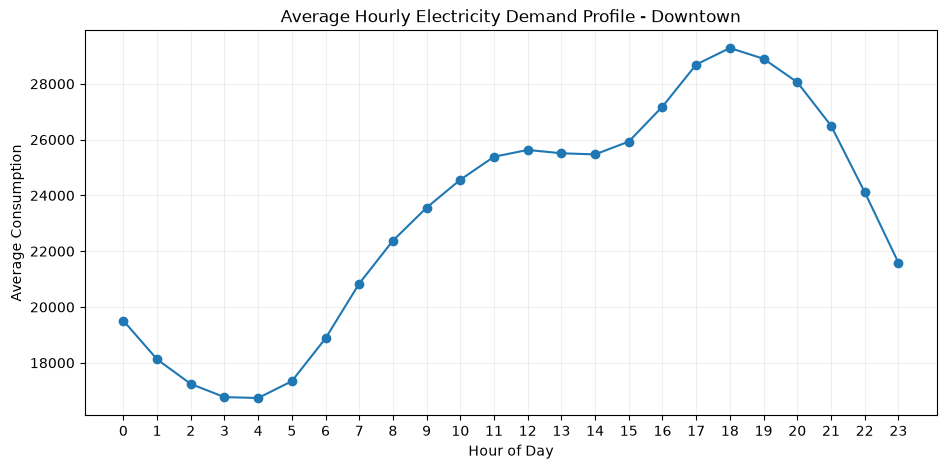

In [21]:
# Average hourly demand profile - Downtown

downtown_hourly = hourly_pattern[
    hourly_pattern["Region"] == "DOWNTOWN"
]

plt.figure(figsize=(11, 5))

plt.plot(
    downtown_hourly["hour"],
    downtown_hourly["mean"],
    marker="o"
)

plt.title("Average Hourly Electricity Demand Profile - Downtown")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.xticks(range(0, 24))
plt.grid(alpha=0.2)

plt.show()

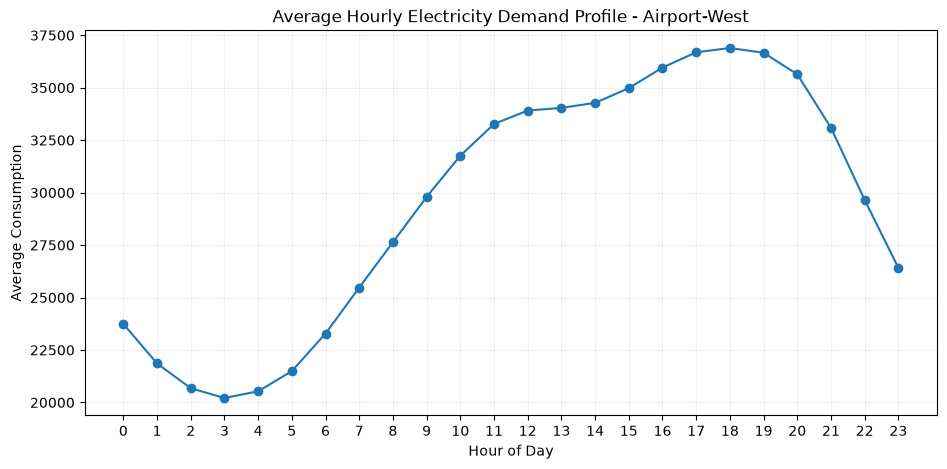

In [22]:
# Average hourly demand profile - Airport-West

airport_hourly = hourly_pattern[
    hourly_pattern["Region"] == "AIRPORT_WEST"
]

plt.figure(figsize=(11, 5))

plt.plot(
    airport_hourly["hour"],
    airport_hourly["mean"],
    marker="o"
)

plt.title("Average Hourly Electricity Demand Profile - Airport-West")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.xticks(range(0, 24))
plt.grid(alpha=0.2)

plt.show()

### Hour-of-Day Pattern Summary

Both regions exhibit a strong and highly structured intraday electricity-demand pattern.

Demand reaches its lowest levels during the early morning hours, begins increasing after approximately 05:00, remains elevated throughout the daytime, and reaches its highest average level around 18:00 before declining during the evening.

Downtown increases from an average minimum of approximately 16,738 at 04:00 to approximately 29,285 at 18:00. Airport-West shows an even larger intraday range, increasing from approximately 20,212 at 03:00 to approximately 36,892 at 18:00.

Airport-West also exhibits substantially greater variability during daytime and afternoon hours.

The consistent 24-hour structure provides strong descriptive evidence of daily seasonality. However, the appropriate seasonal specification for forecasting will be determined later using temporal-dependence diagnostics rather than selected solely from the average hourly profile.

In [23]:
# Average hourly demand by workday/weekend status

hourly_daytype_pattern = []

for region, df in datasets.items():

    temp = df.copy()

    temp["day_type"] = np.where(
        temp["is_weekend"] == 1,
        "Weekend",
        "Weekday"
    )

    pattern = (
        temp.groupby(
            ["day_type", "hour"]
        )["TOTAL_CONSUMPTION"]
        .mean()
        .reset_index()
    )

    pattern["Region"] = region

    hourly_daytype_pattern.append(pattern)

hourly_daytype_pattern = pd.concat(
    hourly_daytype_pattern,
    ignore_index=True
)

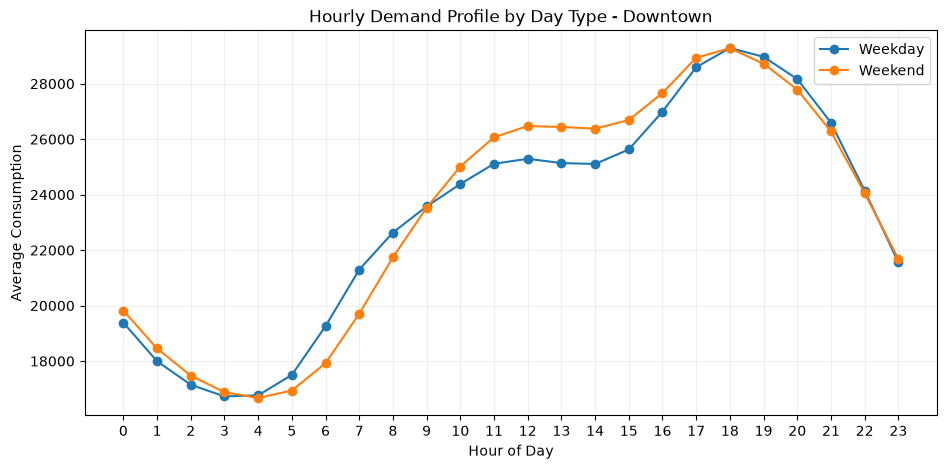

In [24]:
# Downtown hourly profile: weekday vs weekend

plot_data = hourly_daytype_pattern[
    hourly_daytype_pattern["Region"] == "DOWNTOWN"
]

plt.figure(figsize=(11, 5))

for day_type in ["Weekday", "Weekend"]:

    subset = plot_data[
        plot_data["day_type"] == day_type
    ]

    plt.plot(
        subset["hour"],
        subset["TOTAL_CONSUMPTION"],
        marker="o",
        label=day_type
    )

plt.title("Hourly Demand Profile by Day Type - Downtown")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.2)

plt.show()

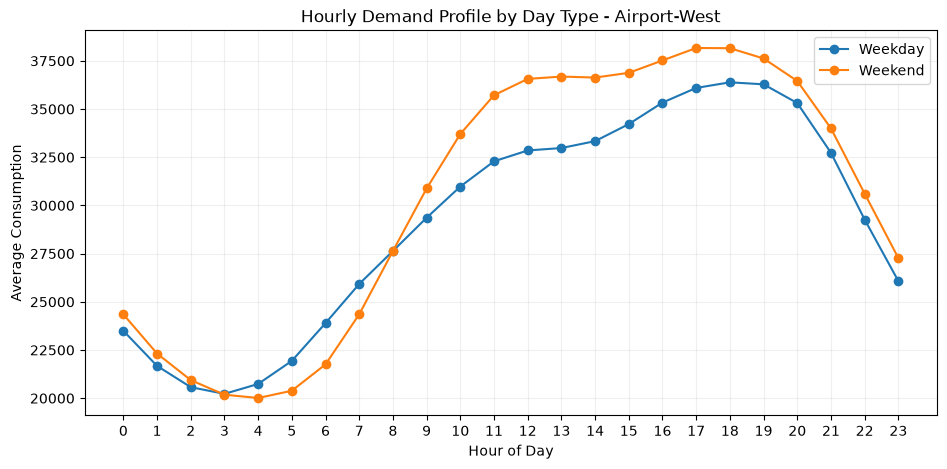

In [25]:
# Airport-West hourly profile: weekday vs weekend

plot_data = hourly_daytype_pattern[
    hourly_daytype_pattern["Region"] == "AIRPORT_WEST"
]

plt.figure(figsize=(11, 5))

for day_type in ["Weekday", "Weekend"]:

    subset = plot_data[
        plot_data["day_type"] == day_type
    ]

    plt.plot(
        subset["hour"],
        subset["TOTAL_CONSUMPTION"],
        marker="o",
        label=day_type
    )

plt.title("Hourly Demand Profile by Day Type - Airport-West")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Hour × Day-Type Interaction Summary

The interaction between hour of day and day type reveals additional temporal structure that was not fully visible from daily averages alone.

Downtown maintains a broadly similar intraday profile on weekdays and weekends. Weekend demand is moderately higher during late morning and afternoon hours, while the profiles converge around the evening peak and remain similar overnight.

Airport-West exhibits a stronger day-type interaction. Weekend electricity demand is consistently higher across much of the daytime and evening period, particularly from mid-morning through the afternoon, while overnight demand remains comparatively similar between weekdays and weekends.

These results indicate that the effect of day type is time-dependent rather than constant throughout the day. This interaction may therefore provide useful information for subsequent nonlinear peak-risk modeling.

In [26]:
# Temperature-demand correlations

temperature_correlation = []

for region, df in datasets.items():

    pearson = df[
        ["Temp (°C)", "TOTAL_CONSUMPTION"]
    ].corr(method="pearson").iloc[0, 1]

    spearman = df[
        ["Temp (°C)", "TOTAL_CONSUMPTION"]
    ].corr(method="spearman").iloc[0, 1]

    temperature_correlation.append({
        "Region": region,
        "Pearson_Correlation": pearson,
        "Spearman_Correlation": spearman
    })

temperature_correlation = pd.DataFrame(
    temperature_correlation
)

temperature_correlation.round(3)

,Region,Pearson_Correlation,Spearman_Correlation
0,DOWNTOWN,-0.084,-0.105
1,AIRPORT_WEST,0.295,0.199


In [27]:
# Temperature bins for nonlinear demand analysis

temperature_bins = np.arange(-30, 46, 5)

temperature_demand_pattern = []

for region, df in datasets.items():

    temp = df.copy()

    temp["temperature_bin"] = pd.cut(
        temp["Temp (°C)"],
        bins=temperature_bins
    )

    pattern = (
        temp.groupby(
            "temperature_bin",
            observed=True
        )["TOTAL_CONSUMPTION"]
        .agg(["mean", "count"])
        .reset_index()
    )

    pattern["temperature_midpoint"] = (
        pattern["temperature_bin"]
        .apply(lambda x: x.mid)
        .astype(float)
    )

    pattern["Region"] = region

    temperature_demand_pattern.append(pattern)

temperature_demand_pattern = pd.concat(
    temperature_demand_pattern,
    ignore_index=True
)

temperature_demand_pattern[
    [
        "Region",
        "temperature_bin",
        "temperature_midpoint",
        "mean",
        "count"
    ]
].round(2)

,Region,temperature_bin,temperature_midpoint,mean,count
0,DOWNTOWN,"(-25, -20]",-22.5,31574.38,6
1,DOWNTOWN,"(-20, -15]",-17.5,30044.81,91
2,DOWNTOWN,"(-15, -10]",-12.5,29794.44,534
3,DOWNTOWN,"(-10, -5]",-7.5,28900.61,2132
4,DOWNTOWN,"(-5, 0]",-2.5,27001.92,4462
5,DOWNTOWN,"(0, 5]",2.5,24044.64,7715
6,DOWNTOWN,"(5, 10]",7.5,20773.65,6612
7,DOWNTOWN,"(10, 15]",12.5,18239.05,5285
8,DOWNTOWN,"(15, 20]",17.5,18831.16,7366
9,DOWNTOWN,"(20, 25]",22.5,24738.82,7140


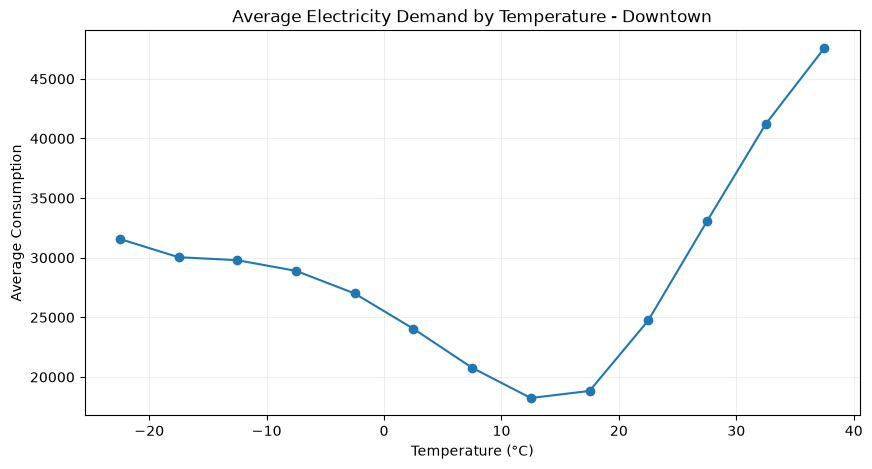

In [28]:
plot_data = temperature_demand_pattern[
    temperature_demand_pattern["Region"] == "DOWNTOWN"
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_data["temperature_midpoint"],
    plot_data["mean"],
    marker="o"
)

plt.title("Average Electricity Demand by Temperature - Downtown")
plt.xlabel("Temperature (°C)")
plt.ylabel("Average Consumption")
plt.grid(alpha=0.2)

plt.show()


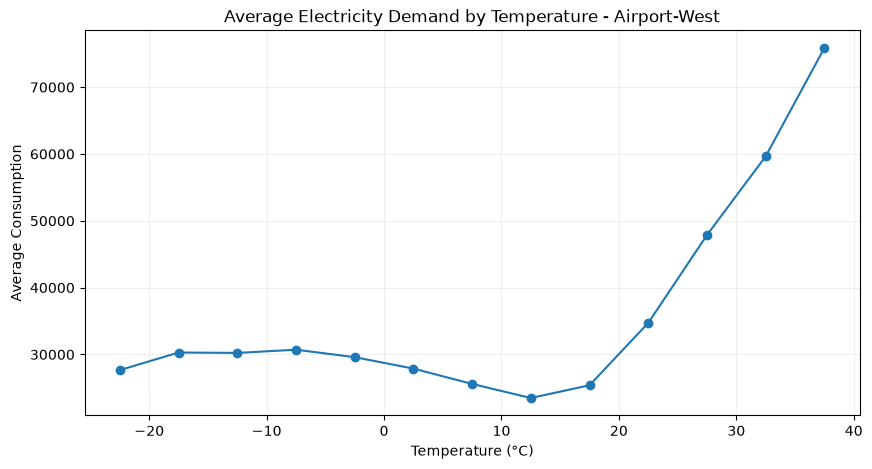

In [29]:
# Temperature-demand relationship - Airport-West

plot_data = temperature_demand_pattern[
    temperature_demand_pattern["Region"] == "AIRPORT_WEST"
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_data["temperature_midpoint"],
    plot_data["mean"],
    marker="o"
)

plt.title("Average Electricity Demand by Temperature - Airport-West")
plt.xlabel("Temperature (°C)")
plt.ylabel("Average Consumption")
plt.grid(alpha=0.2)

plt.show()

In [30]:
# Humidity relationships

humidity_correlation = []

for region, df in datasets.items():

    humidity_demand_pearson = df[
        ["Rel Hum (%)", "TOTAL_CONSUMPTION"]
    ].corr(method="pearson").iloc[0, 1]

    humidity_demand_spearman = df[
        ["Rel Hum (%)", "TOTAL_CONSUMPTION"]
    ].corr(method="spearman").iloc[0, 1]

    temperature_humidity = df[
        ["Temp (°C)", "Rel Hum (%)"]
    ].corr(method="pearson").iloc[0, 1]

    humidity_correlation.append({
        "Region": region,
        "Humidity_Demand_Pearson": humidity_demand_pearson,
        "Humidity_Demand_Spearman": humidity_demand_spearman,
        "Temperature_Humidity_Pearson": temperature_humidity
    })

humidity_correlation = pd.DataFrame(
    humidity_correlation
)

humidity_correlation.round(3)

,Region,Humidity_Demand_Pearson,Humidity_Demand_Spearman,Temperature_Humidity_Pearson
0,DOWNTOWN,-0.167,-0.182,-0.089
1,AIRPORT_WEST,-0.254,-0.255,-0.228


In [31]:
# Examine humidity-demand relationship under different temperature conditions

humidity_temperature_pattern = []

for region, df in datasets.items():

    temp = df.copy()

    temp["temperature_condition"] = pd.cut(
        temp["Temp (°C)"],
        bins=[-np.inf, 10, 20, np.inf],
        labels=["Cold (<10°C)", "Moderate (10–20°C)", "Warm (>20°C)"]
    )

    temp["humidity_bin"] = pd.cut(
        temp["Rel Hum (%)"],
        bins=[0, 40, 60, 80, 100],
        include_lowest=True
    )

    pattern = (
        temp.groupby(
            ["temperature_condition", "humidity_bin"],
            observed=True
        )["TOTAL_CONSUMPTION"]
        .agg(["mean", "count"])
        .reset_index()
    )

    pattern["Region"] = region

    humidity_temperature_pattern.append(pattern)

humidity_temperature_pattern = pd.concat(
    humidity_temperature_pattern,
    ignore_index=True
)

humidity_temperature_pattern[
    [
        "Region",
        "temperature_condition",
        "humidity_bin",
        "mean",
        "count"
    ]
].round(2)

,Region,temperature_condition,humidity_bin,mean,count
0,DOWNTOWN,Cold (<10°C),"(-0.001, 40.0]",24191.48,624
1,DOWNTOWN,Cold (<10°C),"(40.0, 60.0]",25619.63,5934
2,DOWNTOWN,Cold (<10°C),"(60.0, 80.0]",24107.70,10574
3,DOWNTOWN,Cold (<10°C),"(80.0, 100.0]",23021.48,4420
4,DOWNTOWN,Moderate (10–20°C),"(-0.001, 40.0]",20275.95,1107
5,DOWNTOWN,Moderate (10–20°C),"(40.0, 60.0]",19462.68,3326
6,DOWNTOWN,Moderate (10–20°C),"(60.0, 80.0]",18242.46,5186
7,DOWNTOWN,Moderate (10–20°C),"(80.0, 100.0]",17585.73,3032
8,DOWNTOWN,Warm (>20°C),"(-0.001, 40.0]",25744.53,927
9,DOWNTOWN,Warm (>20°C),"(40.0, 60.0]",28402.81,3461


### Humidity–Demand Relationship Summary

Humidity shows a weak negative global association with electricity demand in both regions, but its relationship with demand varies across temperature conditions.

Within moderate temperature conditions (10–20°C), average demand generally decreases as relative humidity increases. Under warm conditions (>20°C), the highest average demand occurs within the 40–60% humidity range rather than at the highest humidity levels. Similar, although less pronounced, nonlinear patterns are observed under cold conditions.

The relatively large number of observations across most temperature–humidity combinations indicates that these patterns are not driven solely by sparse groups. However, this descriptive analysis does not establish an independent humidity effect because other temporal factors may contribute to the observed differences.

Relative humidity will therefore be retained as a candidate predictor for subsequent modeling rather than assumed to provide independent predictive value.

In [32]:
# Key temporal autocorrelations for electricity demand

key_lags = {
    "1_hour": 1,
    "24_hours": 24,
    "48_hours": 48,
    "168_hours": 168,
    "336_hours": 336
}

autocorrelation_results = []

for region, df in datasets.items():

    series = (
        df.sort_values("TIMESTAMP")
          ["TOTAL_CONSUMPTION"]
    )

    result = {"Region": region}

    for name, lag in key_lags.items():
        result[name] = series.autocorr(lag=lag)

    autocorrelation_results.append(result)

autocorrelation_results = pd.DataFrame(
    autocorrelation_results
)

autocorrelation_results.round(3)

,Region,1_hour,24_hours,48_hours,168_hours,336_hours
0,DOWNTOWN,0.974,0.933,0.859,0.755,0.744
1,AIRPORT_WEST,0.977,0.927,0.853,0.778,0.773


### Temporal Autocorrelation Summary

Electricity demand exhibits strong temporal dependence in both regions.

One-hour autocorrelation exceeds 0.97, indicating very high short-term persistence. Autocorrelation remains above 0.92 at a 24-hour lag, providing strong quantitative evidence of the daily demand structure previously observed in the hourly profiles.

Substantial autocorrelation is also present at the 168-hour weekly lag (0.755 for Downtown and 0.778 for Airport-West) and remains high after two weeks.

These results confirm that historical demand contains substantial predictive information at hourly, daily, and weekly horizons. However, the observed autocorrelations are calculated on the original series and may reflect overlapping effects of persistence, seasonality, and non-stationarity. They are therefore not used directly to select SARIMAX orders.

In [33]:
from statsmodels.tsa.stattools import adfuller

adf_results = []

for region, df in datasets.items():

    series = (
        df.sort_values("TIMESTAMP")
          ["TOTAL_CONSUMPTION"]
          .dropna()
    )

    adf = adfuller(
        series,
        autolag="AIC"
    )

    adf_results.append({
        "Region": region,
        "ADF_Statistic": adf[0],
        "p_value": adf[1],
        "Lags_Used": adf[2],
        "Observations": adf[3],
        "Critical_Value_1%": adf[4]["1%"],
        "Critical_Value_5%": adf[4]["5%"],
        "Critical_Value_10%": adf[4]["10%"]
    })

adf_results = pd.DataFrame(adf_results)

adf_results.round(4)

,Region,ADF_Statistic,p_value,Lags_Used,Observations,Critical_Value_1%,Critical_Value_5%,Critical_Value_10%
0,DOWNTOWN,-10.7102,0.0,55,43768,-3.4305,-2.8616,-2.5668
1,AIRPORT_WEST,-10.6473,0.0,51,43772,-3.4305,-2.8616,-2.5668


### Stationarity Assessment

The Augmented Dickey-Fuller (ADF) test strongly rejects the null hypothesis of a unit root for both regional electricity-demand series.

Downtown produces an ADF statistic of -10.7102 and Airport-West -10.6473, with p-values below 0.001 in both cases. These statistics are substantially below the corresponding 1% critical values.

The results therefore provide evidence that regular first-order differencing is not required solely to address a unit root in the original demand series. Consequently, d = 0 will be retained as the initial SARIMAX specification candidate.

This result does not imply the absence of seasonal structure. Strong daily and weekly temporal dependencies identified previously must be assessed separately before determining the seasonal differencing parameter D.

In [34]:
# Evaluate 24-hour seasonal differencing

seasonal_diff_results = []

for region, df in datasets.items():

    series = (
        df.sort_values("TIMESTAMP")
          ["TOTAL_CONSUMPTION"]
          .dropna()
    )

    seasonal_diff = series.diff(24).dropna()

    adf = adfuller(
        seasonal_diff,
        autolag="AIC"
    )

    seasonal_diff_results.append({
        "Region": region,
        "ADF_Statistic_After_Diff24": adf[0],
        "p_value": adf[1],
        "Lag1_ACF": seasonal_diff.autocorr(lag=1),
        "Lag24_ACF": seasonal_diff.autocorr(lag=24),
        "Lag168_ACF": seasonal_diff.autocorr(lag=168),
        "Observations": len(seasonal_diff)
    })

seasonal_diff_results = pd.DataFrame(
    seasonal_diff_results
)

seasonal_diff_results.round(4)

,Region,ADF_Statistic_After_Diff24,p_value,Lag1_ACF,Lag24_ACF,Lag168_ACF,Observations
0,DOWNTOWN,-29.4905,0.0,0.9765,0.0469,0.0080,43800
1,AIRPORT_WEST,-31.3492,0.0,0.9757,0.0136,0.0708,43800


### Seasonal Differencing Diagnostic

A 24-hour seasonal difference substantially reduces the daily and weekly autocorrelation observed in the original electricity-demand series.

For Downtown, lag-24 autocorrelation decreases from 0.933 to 0.047, while lag-168 autocorrelation decreases from 0.755 to 0.008. For Airport-West, the corresponding values decrease from 0.927 to 0.014 and from 0.778 to 0.071.

This indicates that the strong daily cycle accounts for a substantial portion of the longer-lag temporal dependence observed in the original series. The results do not provide strong evidence for modeling an additional independent weekly seasonal structure at this stage.

However, short-term persistence remains extremely high after 24-hour seasonal differencing, with lag-1 autocorrelation remaining approximately 0.976 in both regions.

The diagnostic therefore supports evaluating a 24-hour seasonal structure in SARIMAX, while the choice between D = 0 and D = 1 will be determined through additional diagnostics and out-of-sample model evaluation rather than assumed from the differencing result alone.

In [35]:
# Downtown original and 24-hour differenced series

downtown_series = (
    downtown
    .sort_values("TIMESTAMP")
    .set_index("TIMESTAMP")["TOTAL_CONSUMPTION"]
)

downtown_diff24 = downtown_series.diff(24).dropna()

<Figure size 1200x500 with 0 Axes>

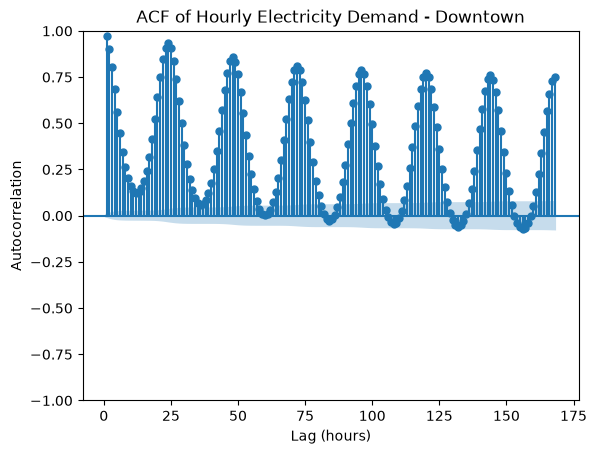

In [36]:
# ACF of original Downtown demand

plt.figure(figsize=(12, 5))

plot_acf(
    downtown_series,
    lags=168,
    zero=False
)

plt.title("ACF of Hourly Electricity Demand - Downtown")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")

plt.show()

<Figure size 1200x500 with 0 Axes>

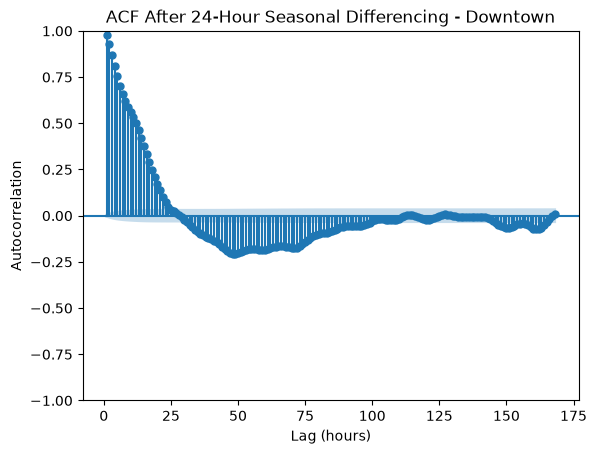

In [37]:
# ACF after 24-hour seasonal differencing

plt.figure(figsize=(12, 5))

plot_acf(
    downtown_diff24,
    lags=168,
    zero=False
)

plt.title("ACF After 24-Hour Seasonal Differencing - Downtown")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")

plt.show()

### Autocorrelation Structure

The ACF of the original Downtown electricity-demand series exhibits pronounced recurring peaks at approximately 24-hour intervals, confirming a strong daily seasonal structure. These peaks persist across the seven-day diagnostic window, although their magnitude gradually decreases over longer lags.

After applying a 24-hour seasonal difference, the recurring daily peaks are substantially removed. This is consistent with the reduction in lag-24 autocorrelation from 0.933 in the original series to approximately 0.047 after seasonal differencing.

The seasonally differenced series nevertheless retains substantial short-term dependence. Its autocorrelation decays gradually across the first several lags and subsequently becomes moderately negative before converging toward zero over longer horizons.

These results provide additional empirical support for evaluating a SARIMAX specification with a 24-hour seasonal period and seasonal differencing (D = 1, s = 24). Final model orders will nevertheless be selected through additional diagnostics and time-based validation rather than from the ACF alone.

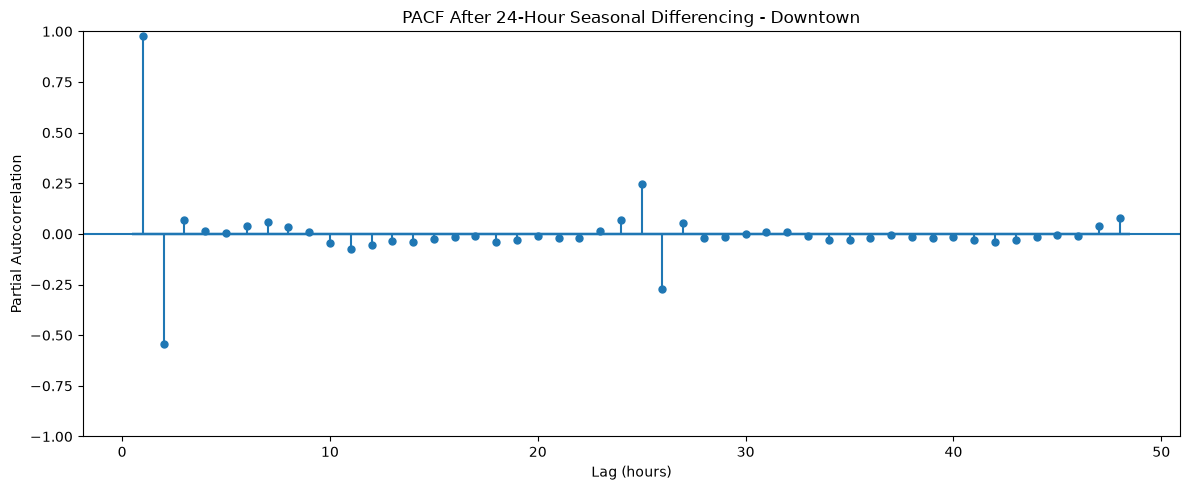

In [38]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    downtown_diff24,
    lags=48,
    method="ywm",
    zero=False,
    ax=ax
)

ax.set_title(
    "PACF After 24-Hour Seasonal Differencing - Downtown"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

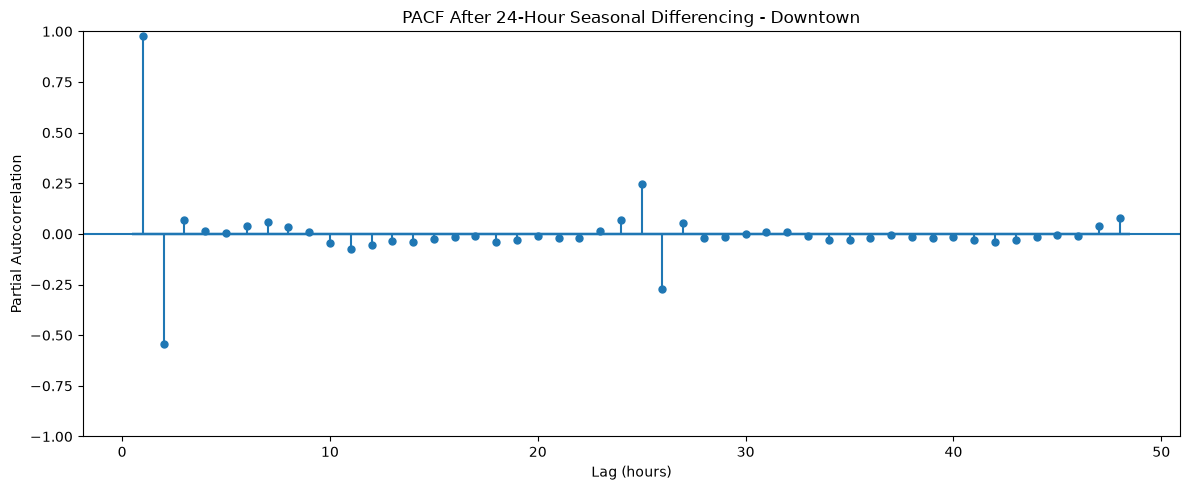

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    downtown_diff24,
    lags=48,
    method="ywm",
    zero=False,
    ax=ax
)

ax.set_title(
    "PACF After 24-Hour Seasonal Differencing - Downtown"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

### Partial Autocorrelation Diagnostic

The PACF of the 24-hour seasonally differenced Downtown demand series is dominated by the first two short-term lags.

Lag 1 exhibits a very strong positive partial autocorrelation, while lag 2 shows a substantial negative partial autocorrelation. Partial autocorrelations beyond these initial lags are considerably smaller, although additional structure remains around the 24-hour seasonal boundary.

This pattern supports evaluating low-order autoregressive specifications rather than high-order AR structures. In particular, p = 1 and p = 2 are retained as candidate non-seasonal autoregressive orders.

The PACF is used only to restrict the candidate model space. Final SARIMAX orders will be determined through time-based out-of-sample evaluation rather than selected directly from individual PACF spikes.

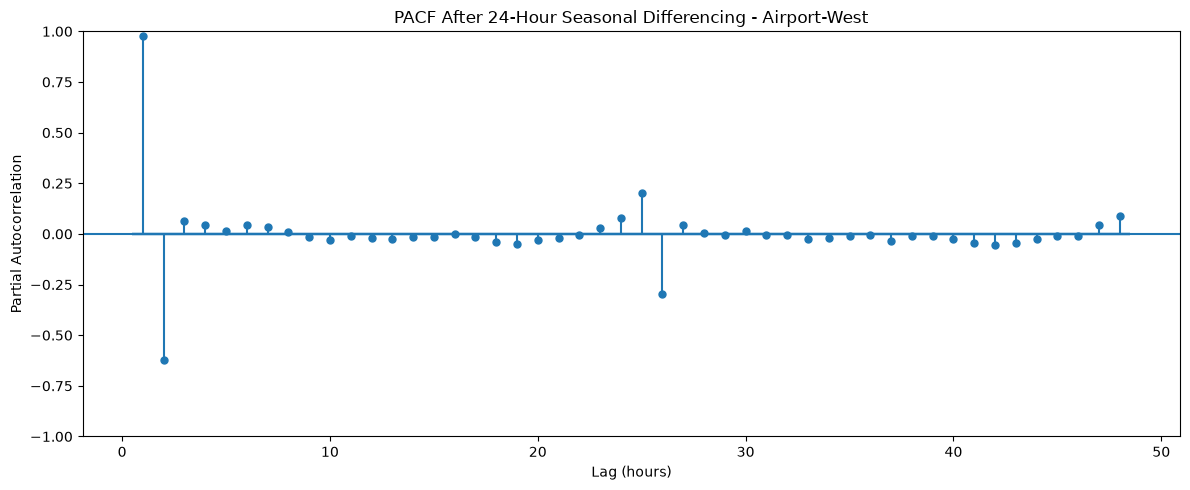

In [40]:
# Airport-West 24-hour seasonally differenced series

airport_series = (
    airport_west
    .sort_values("TIMESTAMP")
    .set_index("TIMESTAMP")["TOTAL_CONSUMPTION"]
)

airport_diff24 = airport_series.diff(24).dropna()

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    airport_diff24,
    lags=48,
    method="ywm",
    zero=False,
    ax=ax
)

ax.set_title(
    "PACF After 24-Hour Seasonal Differencing - Airport-West"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

### Cross-Regional PACF Validation

The Airport-West PACF confirms a short-term dependence structure broadly consistent with Downtown after 24-hour seasonal differencing.

In both regions, lag 1 exhibits a dominant positive partial autocorrelation, followed by a substantial negative effect at lag 2. Partial autocorrelations at subsequent short-term lags are considerably smaller, while some residual structure remains around the 24-hour seasonal boundary.

The consistency across regions supports using the same restricted initial SARIMAX candidate space while fitting and evaluating each regional model independently.

Based on the combined EDA and temporal diagnostics, the initial modeling hypotheses are:

- Regular differencing: d = 0
- Seasonal period: s = 24
- Seasonal differencing: D = 1 as the primary candidate, with D = 0 retained as a comparison
- Non-seasonal AR order: p ∈ {1, 2}
- MA and seasonal AR/MA orders: restricted to low-order candidates and determined through time-based validation

No final SARIMAX specification is selected from ACF/PACF diagnostics alone.

## Temporal Modeling Design

Because the analytical datasets contain hourly time-series observations, model development follows a chronological evaluation strategy. Random shuffling is not used because it would allow future observations to influence model development and would produce an unrealistic estimate of forecasting performance.

The historical period is divided into three sequential blocks:

- Training: January 2021 through June 2024
- Validation: July 2024 through December 2024
- Test: January 2025 through December 2025

The training period is used for parameter estimation, the validation period for model selection, and the complete 2025 period is retained as an untouched final test set.

A full calendar year is reserved for final testing so that model performance is evaluated across all seasons and varying demand conditions.

In [41]:
# Define temporal boundaries

TRAIN_END = pd.Timestamp("2024-06-30 23:00:00")
VALIDATION_END = pd.Timestamp("2024-12-31 23:00:00")

temporal_splits = {}

for region, df in datasets.items():

    df = df.sort_values("TIMESTAMP").copy()

    train = df[
        df["TIMESTAMP"] <= TRAIN_END
    ].copy()

    validation = df[
        (df["TIMESTAMP"] > TRAIN_END) &
        (df["TIMESTAMP"] <= VALIDATION_END)
    ].copy()

    test = df[
        df["TIMESTAMP"] > VALIDATION_END
    ].copy()

    temporal_splits[region] = {
        "train": train,
        "validation": validation,
        "test": test
    }

In [42]:
# Validate temporal splits

split_validation = []

for region, splits in temporal_splits.items():

    for split_name, df in splits.items():

        split_validation.append({
            "Region": region,
            "Split": split_name,
            "Rows": len(df),
            "Start": df["TIMESTAMP"].min(),
            "End": df["TIMESTAMP"].max(),
            "Unique_Timestamps": df["TIMESTAMP"].nunique(),
            "Missing_Consumption":
                df["TOTAL_CONSUMPTION"].isna().sum()
        })

split_validation = pd.DataFrame(split_validation)

split_validation

,Region,Split,Rows,Start,End,Unique_Timestamps,Missing_Consumption
0,DOWNTOWN,train,30648,2021-01-01,2024-06-30 23:00:00,30648,0
1,DOWNTOWN,validation,4416,2024-07-01,2024-12-31 23:00:00,4416,0
2,DOWNTOWN,test,8760,2025-01-01,2025-12-31 23:00:00,8760,0
3,AIRPORT_WEST,train,30648,2021-01-01,2024-06-30 23:00:00,30648,0
4,AIRPORT_WEST,validation,4416,2024-07-01,2024-12-31 23:00:00,4416,0
5,AIRPORT_WEST,test,8760,2025-01-01,2025-12-31 23:00:00,8760,0


In [43]:
# Final integrity check of temporal splits

split_integrity = []

for region, splits in temporal_splits.items():

    train = splits["train"]
    validation = splits["validation"]
    test = splits["test"]

    total_rows = len(train) + len(validation) + len(test)

    split_integrity.append({
        "Region": region,
        "Original_Rows": len(datasets[region]),
        "Split_Rows": total_rows,
        "Row_Conservation":
            total_rows == len(datasets[region]),
        "Train_Validation_Separated":
            train["TIMESTAMP"].max() < validation["TIMESTAMP"].min(),
        "Validation_Test_Separated":
            validation["TIMESTAMP"].max() < test["TIMESTAMP"].min()
    })

split_integrity = pd.DataFrame(split_integrity)

split_integrity

,Region,Original_Rows,Split_Rows,Row_Conservation,Train_Validation_Separated,Validation_Test_Separated
0,DOWNTOWN,43824,43824,True,True,True
1,AIRPORT_WEST,43824,43824,True,True,True


## Forecasting Horizon and Evaluation Framework

The forecasting task is defined as a 24-hour-ahead hourly electricity-demand forecast.

At each forecasting origin, the models are expected to generate predictions for the following 24 hourly periods (h+1 through h+24). This horizon is applied consistently across the forecasting models to support comparable model evaluation.

For SARIMAX, the 24-hour forecast is generated using the model's native multi-step forecasting procedure.

The temporal datasets remain chronologically separated into training, validation, and final test periods. The 2025 test period remains untouched during model development and will be used only for final out-of-sample evaluation.

## EDA Conclusions

The exploratory data analysis identified several characteristics relevant to subsequent electricity-demand forecasting and peak-risk modeling.

### Demand behaviour

Both regions exhibit substantial hourly demand variability and positively skewed demand distributions. Airport-West shows higher average consumption, greater variability, and a more pronounced upper-demand tail than Downtown.

### Temporal structure

Electricity demand exhibits strong recurring temporal patterns:

- clear annual seasonality, with elevated demand during winter and summer;
- a pronounced 24-hour intraday cycle;
- comparatively smaller day-of-week effects;
- stronger weekend effects in Airport-West, particularly during daytime and evening hours.

Demand reaches its lowest average levels during the early morning and generally peaks around 18:00 in both regions.

### Weather relationships

Temperature exhibits a strong nonlinear relationship with electricity demand. Demand is generally lowest under moderate temperatures around 10–15°C and increases under both colder and warmer conditions, with particularly strong warm-weather effects in Airport-West.

Relative humidity shows weaker and non-monotonic relationships with demand and is retained as a candidate predictor rather than assumed to provide independent predictive value.

### Time-series diagnostics

Electricity demand exhibits very strong temporal dependence. Lag-1 autocorrelation exceeds 0.97 and lag-24 autocorrelation exceeds 0.92 in both regions.

A 24-hour seasonal difference substantially removes the recurring daily autocorrelation structure and also reduces much of the apparent weekly dependence.

ADF testing rejects the presence of a regular unit root in both original demand series, supporting d = 0 as the initial non-seasonal differencing hypothesis.

ACF and PACF diagnostics support investigating low-order autoregressive structures and a 24-hour seasonal SARIMAX specification. Seasonal differencing with D = 1 and s = 24 is retained as the primary modeling candidate, while D = 0 remains available for validation comparison.

### Modeling implications

The EDA supports:

- separate regional forecasting models;
- a 24-hour forecasting horizon;
- low-order SARIMAX candidate specifications;
- explicit representation of daily seasonality;
- evaluation of nonlinear temperature effects;
- retention of humidity as a candidate predictor;
- chronological rather than randomly shuffled model evaluation.

Final model specifications and predictor selection will be determined using validation data and out-of-sample performance rather than EDA diagnostics alone.